# CRISPR Edit Outcome Prediction with SMOTE

## Overview
This notebook implements machine learning models to predict CRISPR gene editing outcomes using SMOTE (Synthetic Minority Oversampling Technique) to handle class imbalance. The analysis focuses on predicting editing rates and outcomes for guide RNAs of different lengths (17, 18, and 20 nucleotides).

## Key Components:
1. **Data Loading**: Multiple datasets with different guide RNA lengths
2. **XGBoost Regression**: Predicting fractional editing rates with hyperparameter tuning
3. **SMOTE Classification**: Handling class imbalance for edit outcome prediction
4. **Model Evaluation**: Performance metrics and visualizations

## Datasets:
- Length 20: full_target_table_expts123_dummies_len20.csv
- Length 17: full_target_table_expts123_dummies_len17.csv  
- Length 18: full_target_table_expts123_dummies_len18.csv

## Target Variables:
- `frac_NN_edits`: Fraction of non-neither edits (regression)
- `NN_most`: Most common edit type excluding "neither" (classification)
- `NN_frac_over90/95`: Binary high/low editing rate classification

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from collections import Counter
import xgboost as xgb
import imblearn
from imblearn.over_sampling import SMOTENC

from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

import re


from sklearn.linear_model import LassoCV

from pprint import pprint

## Library Imports

**Core Data Science Libraries:**
- `pandas`, `numpy`: Data manipulation and numerical operations
- `matplotlib.pyplot`, `seaborn`: Data visualization

**Machine Learning Libraries:**
- `sklearn`: Core ML algorithms (RandomForest, LogisticRegression, train_test_split, metrics)
- `xgboost`: Gradient boosting framework for regression and classification
- `imblearn`: Imbalanced learning toolkit, specifically SMOTENC for mixed data types

**Preprocessing & Utilities:**
- `StandardScaler`, `ColumnTransformer`: Feature scaling and preprocessing pipelines
- `GridSearchCV`: Hyperparameter optimization
- `Counter`: Class distribution analysis
- `TSNE`: Dimensionality reduction for visualization
- `LassoCV`: Lasso regression with cross-validation

In [2]:
pd.set_option('display.max_columns', None)

## Data Configuration

In [3]:
len20_df = pd.read_csv('./Data/full_target_table_expts123_dummies_len20.csv', 
                        sep = '\t', index_col = 0)
len17_df = pd.read_csv('./Data/full_target_table_expts123_dummies_len17.csv', 
                        sep = '\t', index_col = 0)
len18_df = pd.read_csv('./Data/full_target_table_expts123_dummies_len18.csv', 
                        sep = '\t', index_col = 0)

In [39]:
len20_df

,target_seq,NN_most,NN_most_code,most,most_code,left_edits,right_edits,both_edits,neither_edits,tot_edits,NN_edits,frac_left_edits,frac_right_edits,frac_both_edits,frac_neither_edits,NN_frac_left_edits,NN_frac_right_edits,NN_frac_both_edits,frac_NN_edits,NN_frac_over95,NN_frac_over90,GC_perc,A_perc,FE,Pos0_A,Pos0_C,Pos0_G,Pos0_T,Pos1_A,Pos1_C,Pos1_G,Pos1_T,Pos2_A,Pos2_C,Pos2_G,Pos2_T,Pos3_A,Pos3_C,Pos3_G,Pos3_T,Pos4_A,Pos4_C,Pos4_G,Pos4_T,Pos5_A,Pos5_C,Pos5_G,Pos5_T,Pos6_A,Pos6_C,Pos6_G,Pos6_T,Pos7_A,Pos7_C,Pos7_G,Pos7_T,Pos8_A,Pos8_C,Pos8_G,Pos8_T,Pos9_A,Pos9_C,Pos9_G,Pos9_T,Pos10_A,Pos10_C,Pos10_G,Pos10_T,Pos11_A,Pos11_C,Pos11_G,Pos11_T,Pos12_A,Pos12_C,Pos12_G,Pos12_T,Pos13_A,Pos13_C,Pos13_G,Pos13_T,Pos14_A,Pos14_C,Pos14_G,Pos14_T,Pos15_A,Pos15_C,Pos15_G,Pos15_T,Pos16_A,Pos16_C,Pos16_G,Pos16_T,Pos17_A,Pos17_C,Pos17_G,Pos17_T,Pos18_A,Pos18_C,Pos18_G,Pos18_T,Pos19_A,Pos19_C,Pos19_G,Pos19_T
0,ATAGTCGCGGCCGCGACTAT,RIGHT,0,NEITHER,0,9,11,2,787,809,22,0.011125,0.013597,0.002472,0.972806,0.409091,0.500000,0.090909,0.027194,0,0,0.6,0.20,-6.5,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1
1,ATTCCACGCGCGCGTGGAAT,RIGHT,0,NEITHER,0,5,10,5,3671,3691,20,0.001355,0.002709,0.001355,0.994581,0.250000,0.500000,0.250000,0.005419,0,0,0.6,0.20,-6.7,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1
2,TCGCTAAGCCGGCTTAGCGA,RIGHT,0,NEITHER,0,23,65,1,2144,2233,89,0.010300,0.029109,0.000448,0.960143,0.258427,0.730337,0.011236,0.039857,0,0,0.6,0.20,-6.4,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0
3,CGATACGTACGTACGTATCG,RIGHT,0,NEITHER,0,29,44,3,1126,1202,76,0.024126,0.036606,0.002496,0.936772,0.381579,0.578947,0.039474,0.063228,0,0,0.5,0.25,-6.7,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
4,GTCCAAACGCGCGTTTGGAC,LEFT,1,NEITHER,0,72,37,7,2984,3100,116,0.023226,0.011935,0.002258,0.962581,0.620690,0.318966,0.060345,0.037419,0,0,0.6,0.20,-6.1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,ACTAGCGGCGCGCCGCTAGT,LEFT,1,NEITHER,0,5,1,1,1272,1279,7,0.003909,0.000782,0.000782,0.994527,0.714286,0.142857,0.142857,0.005473,0,0,0.7,0.15,-7.4,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1
204,CGCTAGACTTAAGTCTAGCG,RIGHT,0,NEITHER,0,7,11,1,123,142,19,0.049296,0.077465,0.007042,0.866197,0.368421,0.578947,0.052632,0.133803,0,0,0.5,0.25,-6.9,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
205,CGCGAGATTGCAATCTCGCG,LEFT,1,NEITHER,0,27,3,1,100,131,31,0.206107,0.022901,0.007634,0.763359,0.870968,0.096774,0.032258,0.236641,0,1,0.6,0.20,-7.9,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0
206,ACGGGTAGCATGCTACCCGT,RIGHT,0,NEITHER,0,1,5,2,399,407,8,0.002457,0.012285,0.004914,0.980344,0.125000,0.625000,0.250000,0.019656,0,0,0.6,0.20,-7.2,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0

## Data Loading

Loading three datasets containing CRISPR editing outcome data for guide RNAs of different lengths:
- **Length 20**: Standard SpCas9 guide RNA length
- **Length 17**: Shorter guide RNA variant  
- **Length 18**: Intermediate length guide RNA

Each dataset contains:
- **Target sequences**: Guide RNA sequences with positional dummy variables
- **Edit outcomes**: Left, right, both, neither edit classifications
- **Edit rates**: Fractional editing frequencies
- **Sequence features**: GC content, nucleotide composition, free energy

In [40]:
len20_df.describe()

,NN_most_code,most_code,left_edits,right_edits,both_edits,neither_edits,tot_edits,NN_edits,frac_left_edits,frac_right_edits,frac_both_edits,frac_neither_edits,NN_frac_left_edits,NN_frac_right_edits,NN_frac_both_edits,frac_NN_edits,NN_frac_over95,NN_frac_over90,GC_perc,A_perc,FE,Pos0_A,Pos0_C,Pos0_G,Pos0_T,Pos1_A,Pos1_C,Pos1_G,Pos1_T,Pos2_A,Pos2_C,Pos2_G,Pos2_T,Pos3_A,Pos3_C,Pos3_G,Pos3_T,Pos4_A,Pos4_C,Pos4_G,Pos4_T,Pos5_A,Pos5_C,Pos5_G,Pos5_T,Pos6_A,Pos6_C,Pos6_G,Pos6_T,Pos7_A,Pos7_C,Pos7_G,Pos7_T,Pos8_A,Pos8_C,Pos8_G,Pos8_T,Pos9_A,Pos9_C,Pos9_G,Pos9_T,Pos10_A,Pos10_C,Pos10_G,Pos10_T,Pos11_A,Pos11_C,Pos11_G,Pos11_T,Pos12_A,Pos12_C,Pos12_G,Pos12_T,Pos13_A,Pos13_C,Pos13_G,Pos13_T,Pos14_A,Pos14_C,Pos14_G,Pos14_T,Pos15_A,Pos15_C,Pos15_G,Pos15_T,Pos16_A,Pos16_C,Pos16_G,Pos16_T,Pos17_A,Pos17_C,Pos17_G,Pos17_T,Pos18_A,Pos18_C,Pos18_G,Pos18_T,Pos19_A,Pos19_C,Pos19_G,Pos19_T
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.0,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.0,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.370192,0.004808,34.100962,55.370192,14.548077,1496.206731,1600.225962,104.019231,0.023572,0.047386,0.009595,0.919447,0.280722,0.552801,0.166477,0.080553,0.052885,0.100962,0.569712,0.215144,-6.762981,0.211538,0.365385,0.254808,0.168269,0.072115,0.394231,0.326923,0.206731,0.216346,0.269231,0.346154,0.168269,0.350962,0.216346,0.245192,0.187500,0.432692,0.182692,0.187500,0.197115,0.567308,0.201923,0.110577,0.120192,0.360577,0.307692,0.216346,0.115385,0.0,0.365385,0.379808,0.254808,0.158654,0.298077,0.394231,0.149038,0.173077,0.350962,0.283654,0.192308,0.192308,0.283654,0.350962,0.173077,0.149038,0.394231,0.298077,0.158654,0.254808,0.379808,0.365385,0.0,0.115385,0.216346,0.307692,0.360577,0.120192,0.110577,0.201923,0.567308,0.197115,0.187500,0.182692,0.432692,0.187500,0.245192,0.216346,0.350962,0.168269,0.346154,0.269231,0.216346,0.206731,0.326923,0.394231,0.072115,0.168269,0.254808,0.365385,0.211538
std,0.646414,0.069338,54.250220,59.126594,21.782579,1112.616110,1160.695374,107.442647,0.033699,0.058652,0.013487,0.086050,0.201550,0.236002,0.185558,0.086050,0.224343,0.302005,0.098765,0.049382,1.217237,0.409385,0.482700,0.436804,0.375008,0.259303,0.489864,0.470221,0.405938,0.412746,0.444630,0.476891,0.375008,0.478422,0.412746,0.431239,0.391254,0.496644,0.387346,0.391254,0.398780,0.496644,0.402404,0.314364,0.325971,0.481326,0.462652,0.412746,0.320256,0.0,0.482700,0.486510,0.436804,0.366234,0.458517,0.489864,0.356986,0.379226,0.478422,0.451858,0.395064,0.395064,0.451858,0.478422,0.379226,0.356986,0.489864,0.458517,0.366234,0.436804,0.486510,0.482700,0.0,0.320256,0.412746,0.462652,0.481326,0.325971,0.314364,0.402404,0.496644,0.398780,0.391254,0.387346,0.496644,0.391254,0.431239,0.412746,0.478422,0.375008,0.476891,0.444630,0.412746,0.405938,0.470221,0.489864,0.259303,0.375008,0.436804,0.482700,0.409385
min,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,49.000000,1.000000,0.000000,0.000000,0.000000,0.456193,0.000000,0.000000,0.000000,0.001368,0.000000,0.000000,0.400000,0.10000

In [34]:
def find_mutated_positions(df):
    """
    Find positions where the target sequence has been mutated from T to other nucleotides.
    Compares the actual nucleotide in target_seq with the Pos*_T indicator columns.
    
    Returns a list of dictionaries containing mutation information for each row.
    """
    mutation_data = []
    
    for idx, row in df.iterrows():
        target_seq = row['target_seq']
        mutated_positions = []
        
        # Check each position (0-19 for length 20 sequences)
        for pos in range(len(target_seq)):
            # Get the actual nucleotide at this position in the target sequence
            actual_nucleotide = target_seq[pos]
            
            # Check if the Pos*_T column indicates this position should have T
            position_column = f'Pos{pos}_A'
            matching_base = 'A'
            if pos > 9:
                position_column = f'Pos{pos}_T'
                matching_base = 'T'
            if position_column in df.columns:
                has_indicator = row[position_column] == 1
                
                # If the indicator says T but the actual nucleotide is not T, it's mutated
                if has_indicator and actual_nucleotide != matching_base:
                    mutated_positions.append({
                        'position': pos,
                        'expected': matching_base,
                        'actual': actual_nucleotide,
                        'mutation': f'{matching_base}>{actual_nucleotide}'
                    })
        
        mutation_data.append({
            'row_index': idx,
            'target_seq': target_seq,
            'mutated_positions': mutated_positions,
            'num_mutations': len(mutated_positions)
        })
    
    return mutation_data

# Find mutations in the first N rows
mutation_results = find_mutated_positions(len20_df.head(1))

# Display results
for result in mutation_results:
    print(f"Row {result['row_index']}: {result['target_seq']}")
    if result['mutated_positions']:
        print(f"  Mutations found at {result['num_mutations']} positions:")
        for mut in result['mutated_positions']:
            print(f"    Position {mut['position']}: {mut['mutation']}")
    else:
        print("  No T mutations detected")
    print()

Row 0: ATAGTCGCGGCCGCGACTAT
  No T mutations detected



### Data Structure Overview

Key columns in the dataset:
- **`target_seq`**: Guide RNA sequence
- **`NN_most`**: Most common edit type (excluding "neither")
- **`most`**: Most common edit type (including "neither")  
- **`*_edits`**: Edit counts for different positions
- **`frac_*_edits`**: Fractional edit rates
- **`GC_perc`, `A_perc`**: Nucleotide composition
- **`FE`**: Free energy of guide RNA
- **`Pos*_*`**: One-hot encoded nucleotide positions

In [5]:

def make_train_test(df):

    X = df.iloc[:, list(df.columns).index('GC_perc'):]
    y = df['frac_NN_edits']

    return(train_test_split(X, y, test_size = 0.2, random_state = 201))


X_train_20, X_test_20, y_train_20, y_test_20 = make_train_test(len20_df)
X_train_18, X_test_18, y_train_18, y_test_18 = make_train_test(len18_df)
X_train_17, X_test_17, y_train_17, y_test_17 = make_train_test(len17_df)

## Train-Test Split Function

Creates consistent train-test splits for all datasets:
- **Features (X)**: All columns from `GC_perc` onwards (sequence features + positional encoding)
- **Target (y)**: `frac_NN_edits` - fraction of non-"neither" edits
- **Test size**: 20% with fixed random state for reproducibility

In [6]:
orig_regressor_20 = xgb.XGBRegressor(eval_metric = 'rmse')
poss_params = {'learning_rate': [0.1, 0.01, 0.001],
                'n_estimators': [10, 100, 500],
                'max_depth': [3,4,5]}

search_20 = GridSearchCV(orig_regressor_20, poss_params, cv = 5).fit(X_train_20, y_train_20)
print(f'search_20 params = {search_20.best_params_}')


edit_rate_regressor_20 = xgb.XGBRegressor(learning_rate = search_20.best_params_['learning_rate'],
                                          n_estimators = search_20.best_params_['n_estimators'],
                                          max_depth = search_20.best_params_['max_depth'],
                                          eval_metric = 'rmse')

edit_rate_regressor_20.fit(X_train_20, y_train_20)

search_20 params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

## XGBoost Regression Models

### Length 18 Model Training

**Hyperparameter Grid Search:**
- `learning_rate`: [0.1, 0.01, 0.001] - Controls boosting step size
- `n_estimators`: [10, 100, 500] - Number of boosting rounds  
- `max_depth`: [3, 4, 5] - Maximum tree depth
- **CV**: 5-fold cross-validation
- **Metric**: RMSE (Root Mean Square Error)

In [7]:
orig_regressor_18 = xgb.XGBRegressor(eval_metric = 'rmse')
poss_params = {'learning_rate': [0.1, 0.01, 0.001],
                'n_estimators': [10, 100, 500],
                'max_depth': [3,4,5]}

search_18 = GridSearchCV(orig_regressor_18, poss_params, cv = 5).fit(X_train_18, y_train_18)
print(f'search_18 params = {search_18.best_params_}')


edit_rate_regressor_18 = xgb.XGBRegressor(learning_rate = search_18.best_params_['learning_rate'],
                                          n_estimators = search_18.best_params_['n_estimators'],
                                          max_depth = search_18.best_params_['max_depth'],
                                          eval_metric = 'rmse')

edit_rate_regressor_18.fit(X_train_18, y_train_18)

search_18 params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 10}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, num_parallel_tree=None, ...)

### Length 17 Model Training

Same hyperparameter grid search approach as Length 17, optimizing for RMSE on fraction of non-"neither" edits.

In [8]:
orig_regressor_17 = xgb.XGBRegressor(eval_metric = 'rmse')
poss_params = {'learning_rate': [0.1, 0.01, 0.001],
                'n_estimators': [10, 100, 500],
                'max_depth': [3,4,5]}

search_17 = GridSearchCV(orig_regressor_17, poss_params, cv = 5).fit(X_train_17, y_train_17)
print(f'search_17 params = {search_17.best_params_}')


edit_rate_regressor_17 = xgb.XGBRegressor(learning_rate = search_17.best_params_['learning_rate'],
                                          n_estimators = search_17.best_params_['n_estimators'],
                                          max_depth = search_17.best_params_['max_depth'],
                                          eval_metric = 'rmse')

edit_rate_regressor_17.fit(X_train_17, y_train_17)

search_17 params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Predictions

Identical hyperparameter optimization for the shortest guide RNA length dataset.

In [9]:
preds_20 = edit_rate_regressor_20.predict(X_test_20)
preds_18 = edit_rate_regressor_18.predict(X_test_18)
preds_17 = edit_rate_regressor_17.predict(X_test_17)

### Model Predictions

Generating predictions on test sets for all three guide RNA lengths using the optimally tuned XGBoost regressors.

### Length 20 Results


Text(0, 0.5, 'XGBoost predicted edit rate')

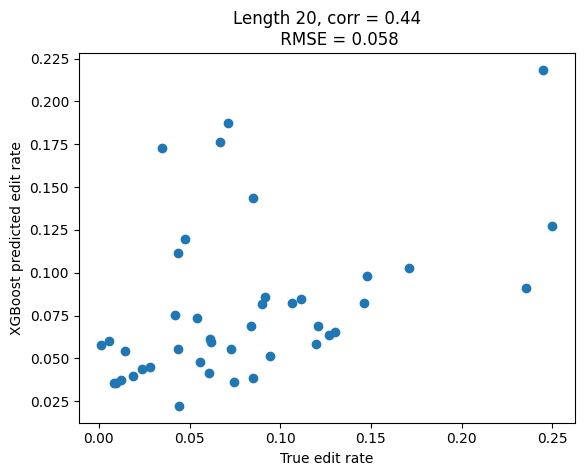

In [10]:
plt.scatter(y_test_20, preds_20)
plt.title(f'Length 20, corr = {round(np.corrcoef(y_test_20, preds_20)[0,1], 2)}\n \
    RMSE = {round(np.sqrt(metrics.mean_squared_error(y_test_20, preds_20)), 3)}')
plt.xlabel('True edit rate')
plt.ylabel('XGBoost predicted edit rate')


## Model Performance Evaluation

Scatter plot comparing true vs predicted edit rates:
- **Correlation coefficient**: Measures linear relationship strength
- **RMSE**: Root Mean Square Error for prediction accuracy
- Perfect predictions would lie on the diagonal line

Text(0, 0.5, 'XGBoost predicted edit rate')

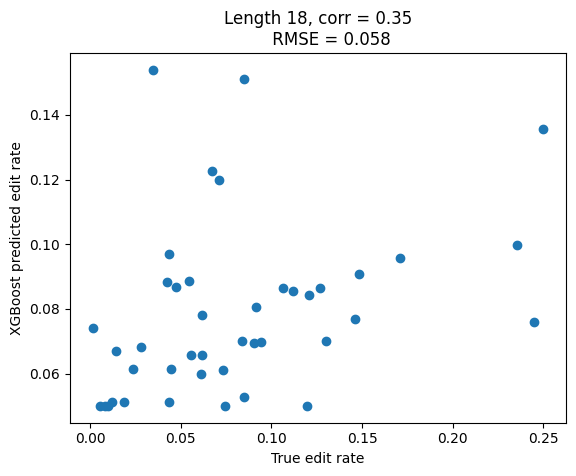

In [41]:
plt.scatter(y_test_18, preds_18)
plt.title(f'Length 18, corr = {round(np.corrcoef(y_test_18, preds_18)[0,1], 2)}\n \
    RMSE = {round(np.sqrt(metrics.mean_squared_error(y_test_18, preds_18)), 3)}')
plt.xlabel('True edit rate')
plt.ylabel('XGBoost predicted edit rate')


### Length 17 Results
Performance evaluation for intermediate-length guide RNA sequences.

Text(0, 0.5, 'XGBoost predicted edit rate')

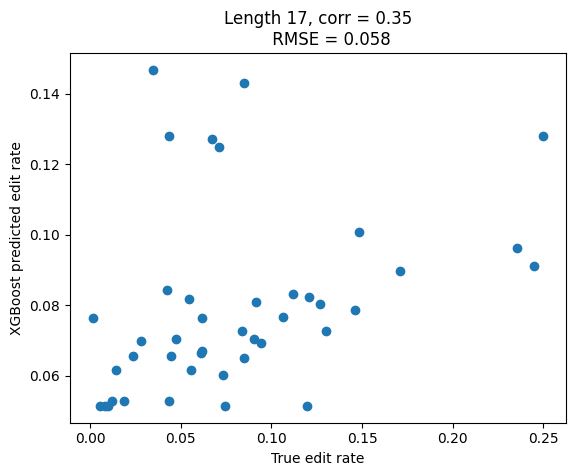

In [42]:
plt.scatter(y_test_17, preds_17)
plt.title(f'Length 17, corr = {round(np.corrcoef(y_test_17, preds_17)[0,1], 2)} \
    RMSE = {round(np.sqrt(metrics.mean_squared_error(y_test_17, preds_17)), 3)}')
plt.xlabel('True edit rate')
plt.ylabel('XGBoost predicted edit rate')


### Length 17 Results  
Performance evaluation for shortest guide RNA sequences.

In [13]:
lasso_20 = LassoCV(alphas = np.arange(0, 1.01, 0.01), cv = 5, random_state = 201).fit(X_train_20, y_train_20)
lasso_20.get_params()

/Users/aaronmck/miniforge3/envs/aiden_PALINCODE/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/Users/aaronmck/miniforge3/envs/aiden_PALINCODE/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.34388222760072185, tolerance: 0.00012093635068945132
  model = cd_fast.enet_coordinate_descent_gram(
/Users/aaronmck/miniforge3/envs/aiden_PALINCODE/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/User

{'alphas': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 100,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': 201,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

## Lasso Regression Alternative

Testing LassoCV as an alternative linear model with L1 regularization:
- **Alpha range**: 0 to 1.0 (regularization strength)
- **Cross-validation**: 5-fold CV for optimal alpha selection
- **Purpose**: Feature selection and linear baseline comparison

Note: Warnings indicate convergence issues and suggest Ridge regression might be more appropriate for this dataset.

In [36]:
!pwd

/dartfs/rc/lab/M/McKennaLab/projects/edit_outcomes/JupNotebooks


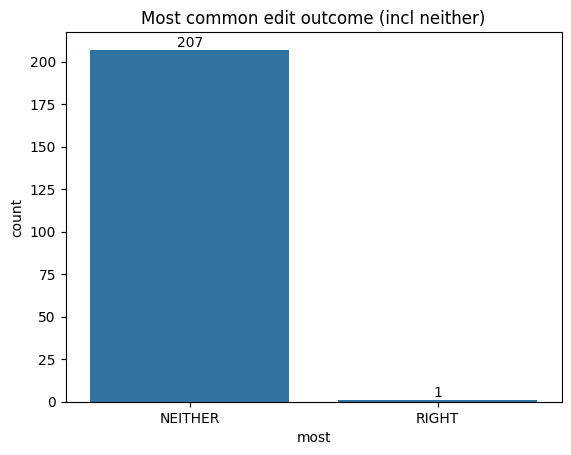

In [14]:
most_dist_plot = sns.countplot(data = len20_df, x = 'most')
plt.title('Most common edit outcome (incl neither)')
for cat in most_dist_plot.containers:
    most_dist_plot.bar_label(cat)
plt.savefig('./revisit_figs/SMOTE_diff_lengths/outcomes_w_neither.png')

## Exploratory Data Analysis

### Edit Outcome Distribution
Visualizing the distribution of edit outcomes including "neither" category to understand class imbalance before SMOTE application.

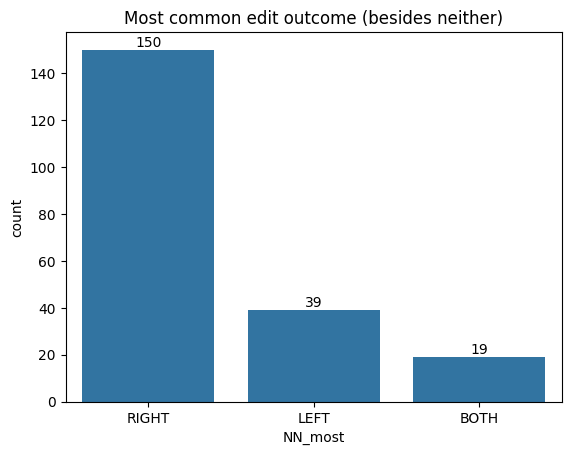

In [15]:
NN_most_dist_plot = sns.countplot(data = len20_df, x = 'NN_most')
plt.title('Most common edit outcome (besides neither)')
for cat in NN_most_dist_plot.containers:
    NN_most_dist_plot.bar_label(cat)
plt.savefig('./revisit_figs/SMOTE_diff_lengths/outcomes_no_neither.png')

### Non-Neither Edit Distribution  
Distribution of edit outcomes excluding "neither" cases - the classes that will be used for SMOTE-based classification.

In [16]:
def factorize_outcome(df):
    factor_NN_most = pd.factorize(df['NN_most'])
    df.insert(loc = list(df.columns).index('NN_most') + 1, column = 'NN_most_code', value = factor_NN_most[0])
    
    factor_most = pd.factorize(df['most'])
    df.insert(loc = list(df.columns).index('most') + 1, column = 'most_code', value = factor_most[0])
    
#     return df, factor_NN_most[1], factor_most[1]
    return df

## Data Preprocessing Functions

### Label Encoding Function
Converts categorical edit outcomes to numerical labels:
- **`NN_most`**: Most common non-"neither" edit type → `NN_most_code`
- **`most`**: Most common edit type (including "neither") → `most_code`
- Uses `pd.factorize()` for consistent encoding across datasets

In [17]:
def make_perc_thresh(df, perc):
    thresh = np.percentile(df['frac_NN_edits'], perc)
    over = [1 if frac >= thresh else 0 for frac in df['frac_NN_edits']]
    df.insert(loc = list(df.columns).index('frac_NN_edits') + 1, column = f'NN_frac_over{perc}', value = over)
    return df

### Percentile Threshold Function
Creates binary classification targets based on edit rate percentiles:
- **Input**: DataFrame and percentile threshold (e.g., 90, 95)
- **Output**: Binary column indicating whether `frac_NN_edits` exceeds the threshold
- **Purpose**: Convert regression problem to binary classification for SMOTE analysis

In [18]:
def preprocess_df(df):
    df = factorize_outcome(df)
    df = make_perc_thresh(df, 90)
    df = make_perc_thresh(df, 95)
    return df

### Complete Preprocessing Pipeline
Applies all preprocessing steps:
1. **Label encoding** for categorical outcomes
2. **90th percentile** binary threshold  
3. **95th percentile** binary threshold

In [19]:
all_len_dfs = [len20_df, len17_df, len18_df]


In [20]:
for df in all_len_dfs:
    df = preprocess_df(df)

In [21]:
def SMOTE_LRB(df):
    
    # determine how long the target sequences in this dataframe are
    tar_len = len(df['target_seq'][0])

    # train test split for both NN and all
    X = df.iloc[:, list(df.columns).index('GC_perc'):]
    y_NN_most = df['NN_most_code']
    y_most = df['most_code']
    
    # split all X and y data into train and test
    X_NN_most_train, X_NN_most_test, y_NN_most_train, y_NN_most_test = train_test_split(X, 
                                                                                        y_NN_most, 
                                                                                        test_size = 0.25, 
                                                                                        random_state = 201)
#     X_most_train, X_most_test, y_most_train, y_most_test = train_test_split(X, y_most, 
#                                                                             test_size = 0.25, 
#                                                                             random_state = 201)
    
    # initialize SMOTE
    smote = SMOTENC(random_state = 908, categorical_features = list(range(3, X.shape[1])))
    
    # only use SMOTE on the training data
    X_NN_most_train_sm, y_NN_most_train_sm = smote.fit_resample(X_NN_most_train, y_NN_most_train)
    
#     X_NN_most_train_sm, X_NN_most_test_sm, y_NN_most_train_sm, y_NN_most_test_sm = train_test_split(X_NN_most_sm, 
#                                                                                                     y_NN_most_sm, 
#                                                                                                     test_size = 0.25, 
#                                                                                                     random_state = 201)
    
#     scaler = StandardScaler()

#     ct_NN_sm = ColumnTransformer([
#             ('name', scaler, ['GC_perc', 'A_perc', 'FE'])
#         ], remainder = 'passthrough')

#     # fit the standard transformer on the SMOTE-bolstered training data
#     X_NN_most_train_sm_tr = ct_NN_sm.fit_transform(X_NN_most_train_sm)
#     # transform the non-SMOTE test X data using this training transformer
#     X_NN_most_test_tr = ct_NN_sm.transform(X_NN_most_test)
    
    # initialize xgb model
    xgb_clf_SMOTE = xgb.XGBClassifier(random_state = 201)
    
    # fit xgb model to only tranformed training data
    xgb_clf_SMOTE.fit(X_NN_most_train_sm, y_NN_most_train_sm)
    most_SMOTE_preds = xgb_clf_SMOTE.predict(X_NN_most_test)
    
    
    
    print(f"Analyzing Target Length {tar_len} Data:")
    print(f"Synthetic training data label counter = {Counter(y_NN_most_train_sm)}")
    print(f"Original label counter = {Counter(y_NN_most_train)}")
    print(f"Length of predictions = {len(most_SMOTE_preds)}")
    print(f"Predictions counter = {Counter(most_SMOTE_preds)}")
    print(f"Precision score: {metrics.precision_score(y_true = y_NN_most_test, y_pred = most_SMOTE_preds, average = 'micro')}")
    print(f"Recall score: {metrics.recall_score(y_true = y_NN_most_test, y_pred = most_SMOTE_preds, average = 'micro')}")
    print(f"Accuracy score: {metrics.accuracy_score(y_true = y_NN_most_test, y_pred = most_SMOTE_preds)}")
    print(f"F1 score: {metrics.f1_score(y_true = y_NN_most_test, y_pred = most_SMOTE_preds, average = 'micro')}")
    print('-'*20)
    
    most_SMOTE_cm = metrics.confusion_matrix(y_true = y_NN_most_test, y_pred = most_SMOTE_preds)
    most_SMOTE_cmdisp = metrics.ConfusionMatrixDisplay(confusion_matrix = most_SMOTE_cm,
                                                     display_labels = ['RIGHT', 'LEFT', 'BOTH'])
    most_SMOTE_cmdisp.plot()
    plt.title(f'SMOTE-driven XGBoost RF Most common NN edit len{tar_len}')
    plt.savefig(f'./revisit_figs/SMOTE_diff_lengths/SMOTE_most_editpos_NN_CM_len{tar_len}.png')


    


## SMOTE Classification Pipeline

### Multi-class Edit Outcome Prediction
**SMOTE-LRB Function**: Handles imbalanced classification for edit types (Left, Right, Both)

**Key Components:**
1. **Data Split**: 75% train, 25% test split
2. **SMOTENC**: Synthetic Minority Oversampling for mixed data types
   - Handles categorical features (positions 3 onwards - one-hot encoded nucleotides)
   - Balances minority classes by generating synthetic samples
3. **XGBoost Classifier**: Trained on SMOTE-augmented data
4. **Evaluation**: Comprehensive metrics (precision, recall, accuracy, F1)
5. **Visualization**: Confusion matrix with class labels

**Why SMOTENC?** 
- Dataset contains both continuous (GC%, A%, FE) and categorical (positional nucleotides) features
- Standard SMOTE assumes all continuous features

Analyzing Target Length 20 Data:
Synthetic training data label counter = Counter({0: 116, 1: 116, 2: 116})
Original label counter = Counter({0: 116, 1: 28, 2: 12})
Length of predictions = 52
Predictions counter = Counter({np.int64(0): 44, np.int64(1): 7, np.int64(2): 1})
Precision score: 0.5769230769230769
Recall score: 0.5769230769230769
Accuracy score: 0.5769230769230769
F1 score: 0.5769230769230769
--------------------
Analyzing Target Length 17 Data:
Synthetic training data label counter = Counter({0: 116, 1: 116, 2: 116})
Original label counter = Counter({0: 116, 1: 28, 2: 12})
Length of predictions = 52
Predictions counter = Counter({np.int64(0): 46, np.int64(1): 4, np.int64(2): 2})
Precision score: 0.6153846153846154
Recall score: 0.6153846153846154
Accuracy score: 0.6153846153846154
F1 score: 0.6153846153846154
--------------------
Analyzing Target Length 18 Data:
Synthetic training data label counter = Counter({0: 116, 1: 116, 2: 116})
Original label counter = Counter({0: 116,

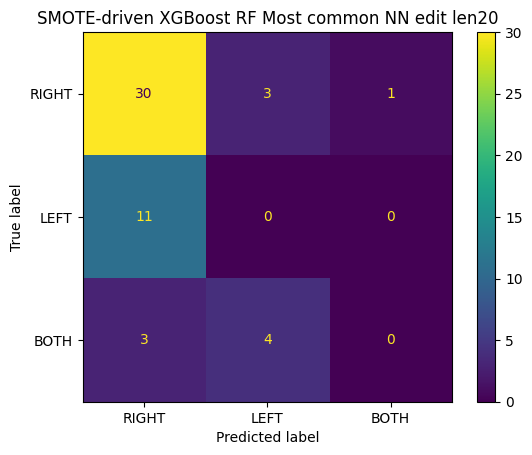

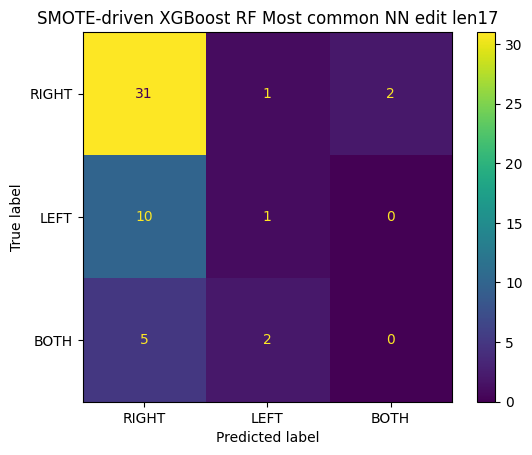

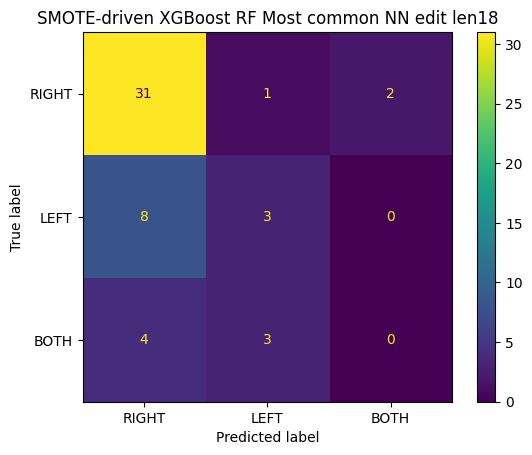

In [22]:
for df in all_len_dfs:
    SMOTE_LRB(df)

### Running Multi-class Classification
Applying SMOTE-based classification to all three guide RNA lengths for edit outcome prediction.

In [62]:
# model can be 'xgb' or 'logreg'
def SMOTE_overX(df, perc, model):
    
    # determine how long the target sequences in this dataframe are
    tar_len = len(df['target_seq'][0])
    
    X = df.iloc[:, list(df.columns).index('GC_perc'):]
    y = df[f'NN_frac_over{perc}']
    
    # split raw data into train and test
    X_topNN_train, X_topNN_test, y_topNN_train, y_topNN_test = train_test_split(X, y, test_size = 0.25, 
                                                                                random_state = 201)
    
    # initialize SMOTE
    smote = SMOTENC(random_state = 908, categorical_features = list(range(3, X.shape[1])))

    
    # fit SMOTE to training data
    X_topNN_train_sm, y_topNN_train_sm = smote.fit_resample(X_topNN_train, y_topNN_train)

    
#     scaler = StandardScaler()
#     ct = ColumnTransformer([
#             ('name', scaler, ['GC_perc', 'A_perc', 'FE'])
#         ], remainder = 'passthrough')

#     # fit scaler to training data, and use same fit on test data
#     X_topNN_train_sm_tr = ct.fit_transform(X_topNN_train_sm)
#     X_topNN_test_sm_tr = ct.transform(X_topNN_test)
    
    
    if model == 'xgb':
        xgb_clf_SMOTE = xgb.XGBClassifier(random_state = 201)
        # fit xgb to SMOTE-bolstered X train data and corresponding y train data
        xgb_clf_SMOTE.fit(X_topNN_train_sm, y_topNN_train_sm)
        # make predictions on not-SMOTE-bolstered X test data
        toptar_SMOTE_preds = xgb_clf_SMOTE.predict(X_topNN_test)
        
        xgb_clf_SMOTE.get_booster().feature_names = list(X.columns)
        xgb_SMOTE_FI = xgb.plot_importance(xgb_clf_SMOTE.get_booster(), max_num_features = 20)
        
        # bst = xgb.train(param, dtrain, num_round, watchlist)
        importance = xgb_clf_SMOTE.get_booster().get_score()
        df = pd.DataFrame(list(importance.items()), columns=["Key", "Value"])
        
        df.to_csv(str(tar_len) + "_feature_selection_2025_08_11.tsv", sep="\t", index=False)  # tab-separated


        plt.title(f'SMOTE-driven {model} RF Top {perc}% NN edit rate feature importance: len{tar_len}')
        plt.savefig(f'./revisit_figs/SMOTE_diff_lengths/SMOTE_{model}_top_{perc}_NN_FI_len{tar_len}.png')
    
    
    elif model == 'logreg':
                
        # initialize logreg model
        top_targ_logmod_sm_mod = LogisticRegression(penalty = 'elasticnet', random_state = 908, 
                                     solver = 'saga', l1_ratio = 0.5, 
                                     class_weight = 'balanced', max_iter = 1000)
        # fit to SMOTE-bolstered X train and corresponding y train data
        top_targ_logmod_sm_mod.fit(X_topNN_train_sm, y_topNN_train_sm)
        # make preds on the unseen X test data
        toptar_SMOTE_preds = top_targ_logmod_sm_mod.predict(X_topNN_test)
        
        coefs = top_targ_logmod_sm_mod.coef_[0]

            
        logreg_import_dict = dict(zip(list(X.columns), coefs))

        # dict with values = abs(coef)
        logreg_abs_import_dict = dict(zip(list(X.columns), np.abs(coefs)))
        # take 20 highest abs value coefs by sorting values
        top20_logreg_abs_import_dict = dict(sorted(logreg_abs_import_dict.items(), key = lambda x: x[1], reverse=True)[:20])

        # make bars blue if they were originally positive coefs or red if negative
        barcols = ['blue' if logreg_import_dict[feat] > 0 else 'red' for feat in top20_logreg_abs_import_dict.keys()]

        bars = plt.barh(list(top20_logreg_abs_import_dict.keys())[::-1], list(top20_logreg_abs_import_dict.values())[::-1])
        for i in range(len(barcols)):
            bars[i].set_color(barcols[i])
        plt.title('Abs value logistic regression FI')
        plt.xlabel('standardized abs(coef value)')
        plt.ylabel('Feature')
        
        color_map = {'negative':'red', 'positive':'blue'}
        posneg = list(color_map.keys())
        rectangles = [plt.Rectangle((0,0), 1, 1, color = color_map[label]) for label in posneg]
        plt.legend(rectangles, color_map)
        
        plt.show()

        
        
        # pprint(logreg_import_dict)

    else:
        print(f'Invalid model')
        return
    
    print(f"Analyzing Target Length {tar_len} Data:")
    print(f"Precision score: {metrics.precision_score(y_true = y_topNN_test, y_pred = toptar_SMOTE_preds, average = 'micro')}")
    print(f"Recall score: {metrics.recall_score(y_true = y_topNN_test, y_pred = toptar_SMOTE_preds, average = 'micro')}")
    print(f"Accuracy score: {metrics.accuracy_score(y_true = y_topNN_test, y_pred = toptar_SMOTE_preds)}")
    print(f"F1 score: {metrics.f1_score(y_true = y_topNN_test, y_pred = toptar_SMOTE_preds, average = 'micro')}")
    print('-'*20)
    
    plt.figure()
    toptar_SMOTE_cm = metrics.confusion_matrix(y_true = y_topNN_test, y_pred = toptar_SMOTE_preds)
    toptar_SMOTE_cmdisp = metrics.ConfusionMatrixDisplay(confusion_matrix = toptar_SMOTE_cm,
                                                     display_labels = [f'Top {100-perc}%', f'Bottom{perc}%'])
    toptar_SMOTE_cmdisp.plot()
    plt.title(f'SMOTE-driven {model} RF Binary Top {perc}% NN edit rates for len{tar_len}')
    plt.show()
    plt.savefig(f'./revisit_figs/SMOTE_diff_lengths/SMOTE_{model}_top_{perc}_perc_guides_NN_CM_len{tar_len}.png')



    

### Binary High-Efficiency Classification  
**SMOTE-overX Function**: Predicts high vs low editing efficiency guides

**Parameters:**
- **`perc`**: Percentile threshold (90 or 95)
- **`model`**: 'xgb' or 'logreg' for different algorithms

**XGBoost Mode:**
- Feature importance visualization (top 20 features)
- Identifies most predictive sequence and compositional features

**Logistic Regression Mode:**  
- ElasticNet regularization (L1 + L2) with balanced class weights
- Color-coded coefficient visualization (blue=positive, red=negative)
- Shows which features increase/decrease high-efficiency probability

**Output:**
- Performance metrics for binary classification
- Confusion matrices comparing top vs bottom percentile guides

Analyzing Target Length 20 Data:
Precision score: 0.8653846153846154
Recall score: 0.8653846153846154
Accuracy score: 0.8653846153846154
F1 score: 0.8653846153846154
--------------------


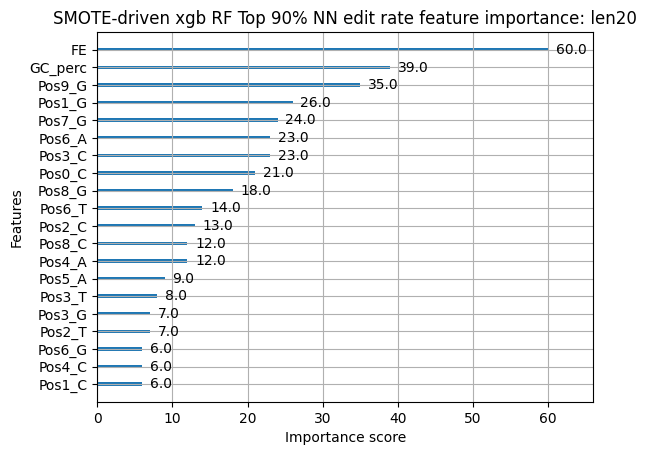

<Figure size 640x480 with 0 Axes>

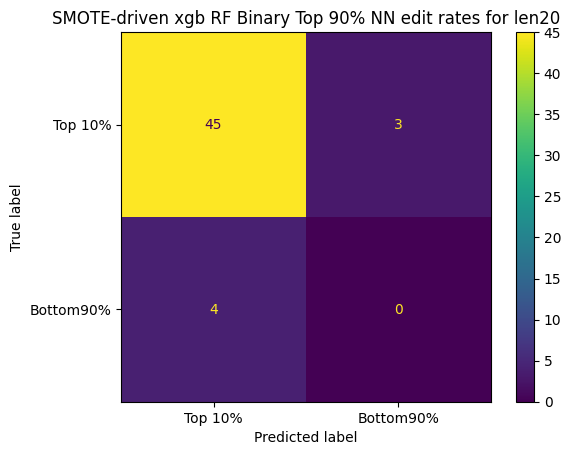

Analyzing Target Length 17 Data:
Precision score: 0.8461538461538461
Recall score: 0.8461538461538461
Accuracy score: 0.8461538461538461
F1 score: 0.8461538461538461
--------------------


<Figure size 640x480 with 0 Axes>

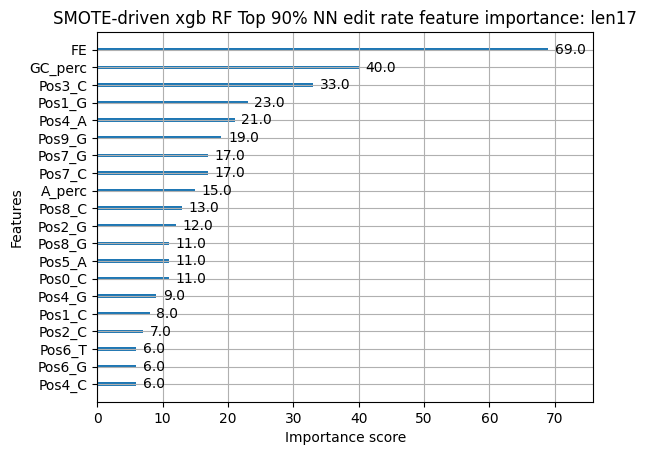

<Figure size 640x480 with 0 Axes>

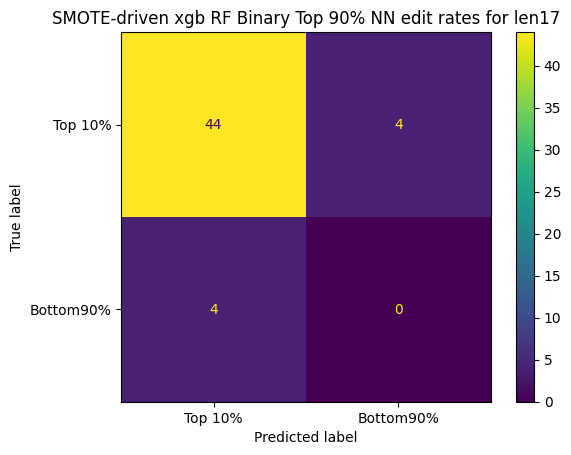

Analyzing Target Length 18 Data:
Precision score: 0.8846153846153846
Recall score: 0.8846153846153846
Accuracy score: 0.8846153846153846
F1 score: 0.8846153846153846
--------------------


<Figure size 640x480 with 0 Axes>

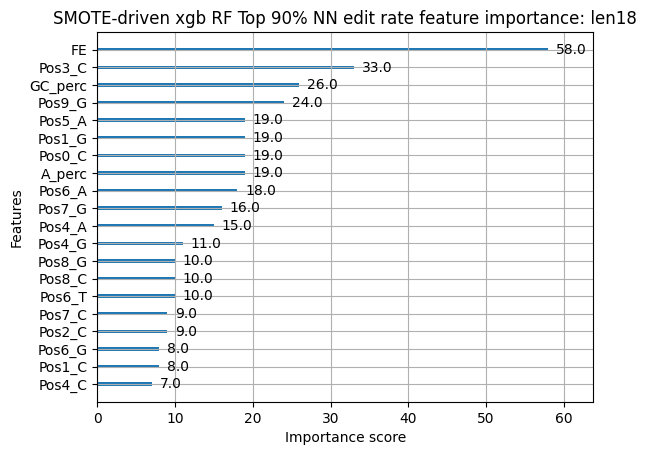

<Figure size 640x480 with 0 Axes>

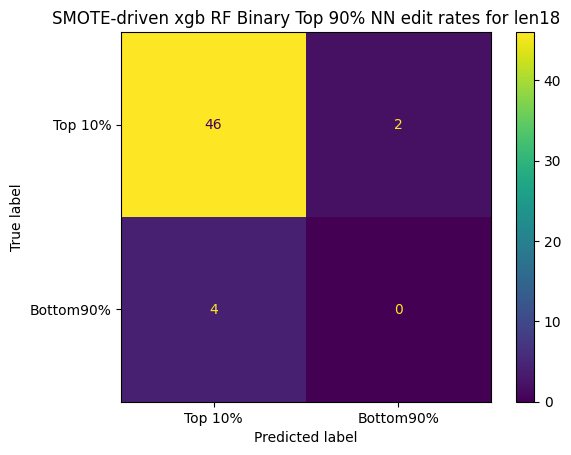

<Figure size 640x480 with 0 Axes>

In [63]:
all_len_dfs = [len20_df, len17_df, len18_df]
for df in all_len_dfs:
    SMOTE_overX(df, 90, 'xgb')

## Experimental Results

### XGBoost Binary Classification (90th Percentile)
Running high-efficiency guide prediction using XGBoost across all guide RNA lengths:
- **Threshold**: 90th percentile of `frac_NN_edits`
- **Algorithm**: XGBoost with SMOTE balancing
- **Output**: Feature importance plots and performance metrics

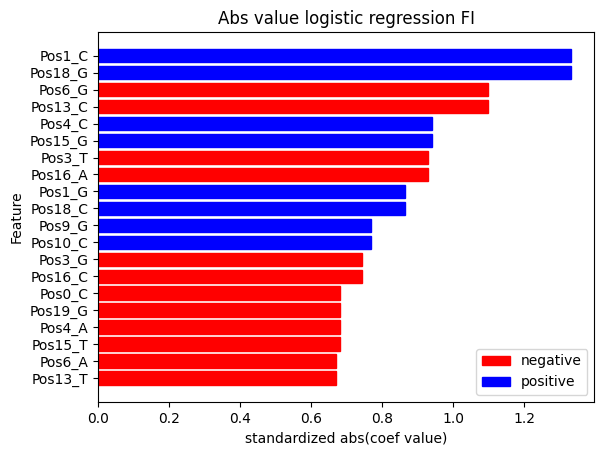

Analyzing Target Length 20 Data:
Precision score: 0.8461538461538461
Recall score: 0.8461538461538461
Accuracy score: 0.8461538461538461
F1 score: 0.8461538461538461
--------------------


<Figure size 640x480 with 0 Axes>

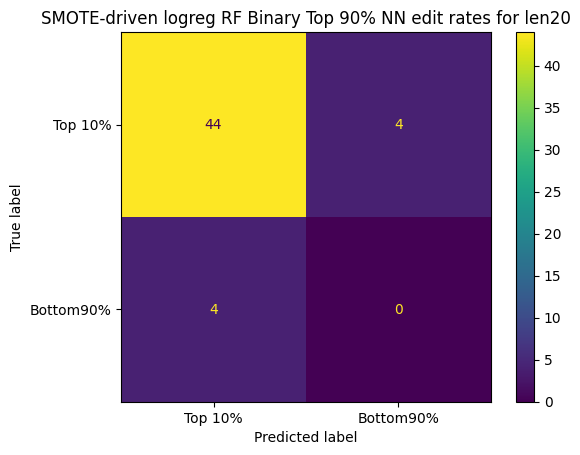

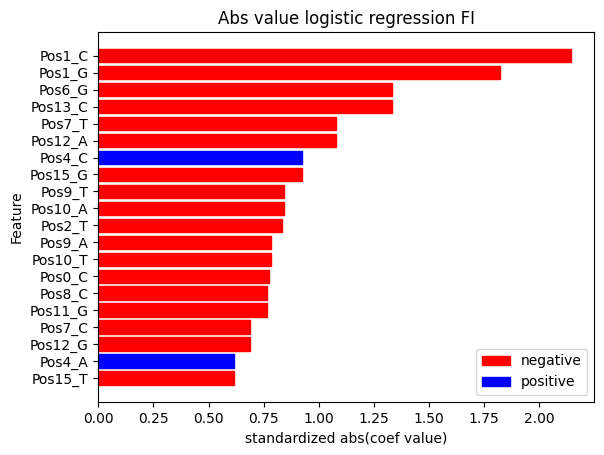

Analyzing Target Length 17 Data:
Precision score: 0.8653846153846154
Recall score: 0.8653846153846154
Accuracy score: 0.8653846153846154
F1 score: 0.8653846153846154
--------------------


<Figure size 640x480 with 0 Axes>

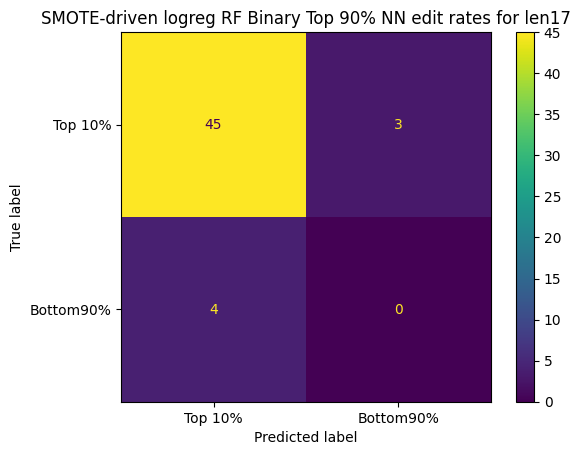

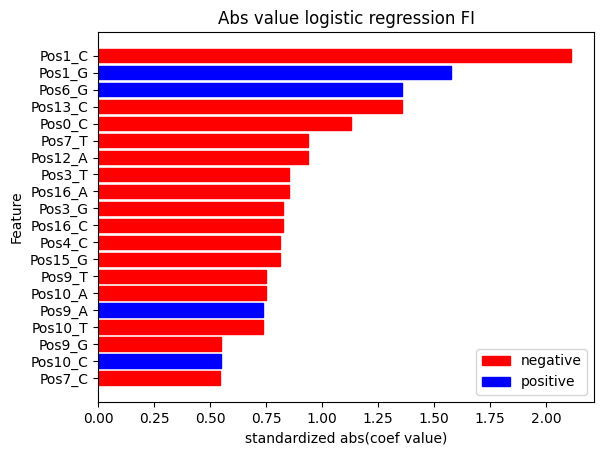

Analyzing Target Length 18 Data:
Precision score: 0.8461538461538461
Recall score: 0.8461538461538461
Accuracy score: 0.8461538461538461
F1 score: 0.8461538461538461
--------------------


<Figure size 640x480 with 0 Axes>

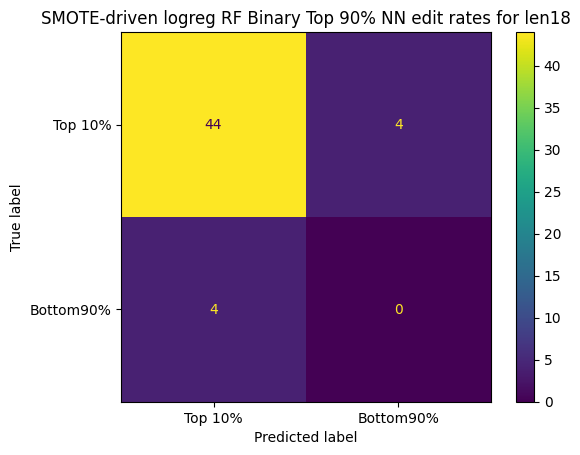

<Figure size 640x480 with 0 Axes>

In [27]:
all_len_dfs = [len20_df, len17_df, len18_df]
for df in all_len_dfs:
    SMOTE_overX(df, 90, 'logreg')

### Logistic Regression Binary Classification (90th Percentile)  
Comparing XGBoost results with regularized logistic regression:
- **Algorithm**: ElasticNet logistic regression with SMOTE
- **Benefits**: Interpretable coefficients, linear decision boundaries
- **Feature Analysis**: Positive/negative coefficient visualization
- **Comparison**: Linear vs tree-based approach performance

## Summary

This notebook demonstrates a comprehensive approach to CRISPR edit outcome prediction:

### Key Findings:
1. **XGBoost Regression**: Successful prediction of continuous edit rates across guide lengths
2. **SMOTE Effectiveness**: Balanced minority classes for improved classification performance  
3. **Multi-class vs Binary**: Both edit type prediction and efficiency classification approaches
4. **Algorithm Comparison**: XGBoost vs Logistic Regression trade-offs (performance vs interpretability)

### Technical Contributions:
- **SMOTENC Usage**: Proper handling of mixed continuous/categorical CRISPR features
- **Cross-length Analysis**: Consistent methodology across 17, 18, and 20 nt guides
- **Feature Engineering**: Positional nucleotide encoding + compositional features
- **Evaluation Framework**: Multiple metrics and visualization approaches

### Applications:
- **Guide Design**: Identify high-efficiency guide RNAs
- **Outcome Prediction**: Anticipate edit types (left, right, both)
- **Feature Analysis**: Understand sequence determinants of editing outcomes